# EFW Annual (2000–2023) × Elections × Macro (Presentable)

Builds the annual panel, election timing features, merges macro, and produces descriptive event-time plots.

In [1]:

from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import yaml
from datetime import datetime
from IPython.display import display

pd.options.mode.copy_on_write = True

%matplotlib inline


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / 'data').exists() and (p / 'notebooks').exists():
            return p
    raise ValueError('Repo root not found; expected data/ and notebooks/ in a parent directory')

ROOT = find_repo_root()

PATHS = {
    'data_processed': ROOT / 'data' / 'processed',
    'data_raw': ROOT / 'data' / 'raw',
    'reports': ROOT / 'reports',
}


def read_parquet_pyarrow(path: str | Path) -> pd.DataFrame:
    table = pq.read_table(str(path))
    return table.to_pandas()


def write_parquet_pyarrow(df: pd.DataFrame, path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    table = pa.Table.from_pandas(df, preserve_index=False)
    pq.write_table(table, str(path))


AUDIT_LOG = []


def log_df(df: pd.DataFrame, step: str, keys: list[str] | None = None, notes: str = "") -> None:
    row = {
        'step': step,
        'n_rows': int(len(df)),
        'n_cols': int(df.shape[1]),
        'n_iso3': int(df['iso3'].nunique(dropna=True)) if 'iso3' in df.columns else None,
        'notes': notes,
    }
    if keys:
        row['n_dupe_rows_on_keys'] = int(df.duplicated(subset=keys).sum())
    AUDIT_LOG.append(row)


def assert_unique(df: pd.DataFrame, keys: list[str], allow_na: bool = False) -> None:
    if not allow_na and df[keys].isna().any().any():
        raise AssertionError(f"Missing values in key columns {keys}")
    dupes = df.duplicated(subset=keys)
    if dupes.any():
        raise AssertionError(f"Duplicate rows found on keys {keys}: {int(dupes.sum())}")


def assert_in_set(df: pd.DataFrame, col: str, allowed: set[str]) -> None:
    bad = set(df[col].dropna().unique()) - set(allowed)
    if bad:
        raise AssertionError(f"Column {col} has values outside allowed set: {bad}")


def assert_bounds(df: pd.DataFrame, col: str, lo: float, hi: float, tol: float = 1e-9, allow_na: bool = True) -> None:
    s = df[col]
    if not allow_na:
        s = s.dropna()
    bad = s[(s < lo - tol) | (s > hi + tol)]
    if not bad.empty:
        raise AssertionError(f"Column {col} has {len(bad)} values outside bounds [{lo},{hi}]")


def log_merge(left: pd.DataFrame, right: pd.DataFrame, on: list[str], how: str, step: str) -> pd.DataFrame:
    merged = left.merge(right, on=on, how=how, indicator=True)
    row = {
        'step': step,
        'left_rows': int(len(left)),
        'right_rows': int(len(right)),
        'merged_rows': int(len(merged)),
        'matched_rows': int((merged['_merge'] == 'both').sum()),
        'left_only_rows': int((merged['_merge'] == 'left_only').sum()),
        'right_only_rows': int((merged['_merge'] == 'right_only').sum()),
        'on_keys': ','.join(on),
        'how': how,
    }
    AUDIT_LOG.append(row)
    return merged.drop(columns=['_merge'])


def show_table(df: pd.DataFrame, title: str | None = None, n: int | None = None) -> None:
    if title:
        print(title)
    if n is None:
        display(df)
    else:
        display(df.head(n))


In [2]:
# Load annual EFW panel
PATH_EFW = ROOT / 'efw.xlsx'
ef = pd.read_excel(PATH_EFW, sheet_name='EFW Panel Dataset')

rename_map = {
    'ISO_Code':'iso3',
    'Year':'year',
    'Summary':'efw_total',
    'Area 1':'efw_area1',
    'Area 2':'efw_area2',
    'Area 3':'efw_area3',
    'Area 4':'efw_area4',
    'Area 5':'efw_area5',
    'World Bank Region':'wb_region',
    'World Bank Current Income Classification, 1990-Present':'wb_income'
}
for k,v in rename_map.items():
    if k in ef.columns:
        ef = ef.rename(columns={k:v})

# Filter 2000-2023
panel = ef[(ef['year'] >= 2000) & (ef['year'] <= 2023)].copy()
assert_unique(panel, ['iso3','year'])
log_df(panel, 'loaded_efw_annual', keys=['iso3','year'])
print('Annual panel rows:', len(panel))


Annual panel rows: 3960


In [3]:
# Load quinquennial panel for overlap validation (from Notebook 2 output)
q_path = PATHS['data_processed'] / 'panel_efw_quinquennial.parquet'
if q_path.exists():
    qpanel = read_parquet_pyarrow(q_path)
    qyears = {2000,2005,2010,2015,2020}
    overlap = panel[panel['year'].isin(qyears)].merge(
        qpanel[['iso3','year','efw_total']], on=['iso3','year'], suffixes=('_annual','_quin')
    )
    if not overlap.empty:
        overlap['abs_diff'] = (overlap['efw_total_annual'] - overlap['efw_total_quin']).abs()
        print('max abs diff (annual vs quin):', overlap['abs_diff'].max())
        write_parquet_pyarrow(overlap[['iso3','year','abs_diff']], PATHS['reports'] / 'efw_annual_audit' / 'efw_overlap_diff.parquet')
        show_table(overlap.head(10), title='Annual vs Quinquennial Overlap (first 10)')


max abs diff (annual vs quin): 0.0
Annual vs Quinquennial Overlap (first 10)


,iso3,Countries,year,efw_total_annual,efw_area1,efw_area2,efw_area3,efw_area4,efw_area5,Standard Deviation of the 5 EFW Areas,wb_region,wb_income,efw_total_quin,abs_diff
0,ALB,Albania,2020,7.609934,7.518879,5.509294,9.682076,8.444843,6.904325,1.573983,Europe & Central Asia,Upper-Middle Income,7.609934,0.0
1,DZA,Algeria,2020,4.818635,4.347384,3.797965,7.852496,3.753452,4.324690,1.720951,Middle East & North Africa,Lower-Middle Income,4.818635,0.0
2,AGO,Angola,2020,5.020271,7.742197,3.428837,3.597565,5.499357,4.813345,1.749135,Sub-Saharan Africa,Lower-Middle Income,5.020271,0.0
3,ARG,Argentina,2020,4.609710,6.026847,5.432385,3.254209,3.102984,5.236647,1.340310,Latin America & the Caribbean,Upper-Middle Income,4.609710,0.0
4,ARM,Armenia,2020,7.380107,7.963568,5.835687,9.336790,7.485670,6.255804,1.399050,Europe & Central Asia,Upper-Middle Income,7.380107,0.0
5,AUS,Australia,2020,8.089925,6.066772,8.687060,9.454963,8.111291,8.107887,1.256357,East Asia & Pacific,High Income,8.089925,0.0
6,AUT,Austria,2020,7.480119,4.884396,8.553453,8.799329,8.382104,6.800584,1.651167,Europe & Central Asia,High Income,7.480119,0.0
7,AZE,Azerbaijan,2020,6.021913,4.453691,4.630433,8.404444,7.000922,5.565465,1.676171,Europe & Central Asia,Upper-Middle Income,6.021913,0.0
8,BHS,"Bahamas, The",2020,6.670333,8.365642,6.303842,6.556802,5.022011,7.083028,1.215368,Latin America & the Caribbean,High Income,6.670333,0.0
9,BHR,Bahrain,2020,7.310135,7.176989,4.302311,9.312392,8.198009,7.539616,1.865117,Middle East & North Africa,High Income,7.310135,0.0


In [4]:
# Load elections DPI dataset
PATH_ELEC = PATHS['data_processed'] / 'elections_master_dpi.parquet'
elec = read_parquet_pyarrow(PATH_ELEC)
if 'efw_post2000' in elec.columns:
    elec = elec[elec['efw_post2000'] == True].copy()

# Ensure election_date present for post-2000
print('missing election_date:', elec['election_date'].isna().sum())
log_df(elec, 'loaded_elections_post2000', keys=['event_id'])
print('post-2000 elections:', len(elec))


missing election_date: 0
post-2000 elections: 1397


In [5]:
# Annual election features

def build_annual_election_features(elec: pd.DataFrame) -> pd.DataFrame:
    elec = elec.copy()
    # Fill date for ordering
    elec['election_date_filled'] = elec['election_date']
    elec.loc[elec['election_date_filled'].isna(), 'election_date_filled'] = pd.to_datetime(
        elec.loc[elec['election_date_filled'].isna(), 'election_year'].astype(int).astype(str) + '-12-31'
    )

    # Previous election info
    elec = elec.sort_values(['iso3','election_date_filled'])
    elec['prev_winner_partyfacts_id'] = elec.groupby('iso3')['winner_partyfacts_id'].shift(1)
    elec['prev_winner_ideo_vparty'] = elec.groupby('iso3')['winner_ideo_vparty'].shift(1)
    elec['prev_election_year'] = elec.groupby('iso3')['election_year'].shift(1)

    elec['turnover_party'] = (
        elec['winner_partyfacts_id'].notna() &
        elec['prev_winner_partyfacts_id'].notna() &
        (elec['winner_partyfacts_id'] != elec['prev_winner_partyfacts_id'])
    )
    elec['ideology_swing'] = elec['winner_ideo_vparty'] - elec['prev_winner_ideo_vparty']

    # Collapse to year: last election in year
    elec_year = elec.sort_values(['iso3','election_year','election_date_filled']).groupby(['iso3','election_year']).tail(1)

    yearly = elec_year[[
        'iso3','election_year','office_type','share_metric','market_margin','close_5pp','winner_ideo_vparty',
        'turnover_party','ideology_swing'
    ]].copy()
    yearly = yearly.rename(columns={
        'election_year':'year',
        'office_type':'elec_last_office_type',
        'share_metric':'elec_last_share_metric',
        'market_margin':'elec_last_market_margin',
        'close_5pp':'elec_last_close_5pp',
        'winner_ideo_vparty':'elec_last_winner_ideo',
        'turnover_party':'elec_turnover_party',
        'ideology_swing':'elec_ideology_swing'
    })

    # Indicators for any election in year
    any_year = elec.groupby(['iso3','election_year']).size().reset_index(name='n_elections_year')
    any_year['elec_election_any'] = any_year['n_elections_year'] > 0
    # By office type
    by_office = elec.pivot_table(index=['iso3','election_year'], columns='office_type', values='event_id', aggfunc='count', fill_value=0)
    by_office = by_office.reset_index().rename(columns={'election_year':'year','parliamentary':'elec_election_parl','presidential':'elec_election_pres'})
    by_office['elec_election_parl'] = by_office['elec_election_parl'] > 0
    by_office['elec_election_pres'] = by_office['elec_election_pres'] > 0

    annual = any_year.rename(columns={'election_year':'year'}).merge(yearly, on=['iso3','year'], how='left')
    annual = annual.merge(by_office, on=['iso3','year'], how='left')

    return annual

annual_features = build_annual_election_features(elec)
show_table(annual_features.head(10), title='Annual Election Features (first 10)')


Annual Election Features (first 10)


,iso3,year,n_elections_year,elec_election_any,elec_last_office_type,elec_last_share_metric,elec_last_market_margin,elec_last_close_5pp,elec_last_winner_ideo,elec_turnover_party,elec_ideology_swing,elec_election_parl,elec_election_pres
0,AGO,2008.0,1,True,parliamentary,seat_share,-79.545455,False,-0.618,False,NaN,True,False
1,AGO,2012.0,1,True,parliamentary,seat_share,-53.846154,False,-0.007,False,0.611,True,False
2,AGO,2017.0,1,True,parliamentary,seat_share,-44.394619,False,-0.007,False,0.000,True,False
3,AGO,2022.0,1,True,parliamentary,seat_share,-15.454545,False,-0.007,False,0.000,True,False
4,ALB,2001.0,2,True,parliamentary,seat_share,NaN,<NA>,-1.066,False,0.000,True,False
5,ALB,2005.0,1,True,parliamentary,seat_share,NaN,<NA>,NaN,False,NaN,True,False
6,ALB,2009.0,1,True,parliamentary,seat_share,NaN,<NA>,NaN,False,NaN,True,False
7,ALB,2013.0,1,True,parliamentary,seat_share,NaN,<NA>,NaN,False,NaN,True,False
8,ALB,2017.0,1,True,parliamentary,seat_share,-22.142857,False,-0.548,False,NaN,True,False
9,ALB,2021.0,1,True,parliamentary,seat_share,-10.714286,False,-0.548,False,0.000,True,False


In [6]:
# Merge annual election features into EFW panel
panel = panel.merge(annual_features, on=['iso3','year'], how='left')

# Last election year (as-of) and years since
panel = panel.sort_values(['iso3','year'])
last_years = []
next_years = []
for iso3, g in panel.groupby('iso3'):
    years = g['year'].tolist()
    elec_years = sorted(elec[elec['iso3'] == iso3]['election_year'].dropna().unique())
    for y in years:
        last = max([e for e in elec_years if e <= y], default=np.nan)
        nxt = min([e for e in elec_years if e >= y], default=np.nan)
        last_years.append({'iso3': iso3, 'year': y, 'elec_last_year': last, 'elec_years_since': y - last if pd.notna(last) else np.nan})
        next_years.append({'iso3': iso3, 'year': y, 'elec_next_year': nxt, 'elec_years_to_next': nxt - y if pd.notna(nxt) else np.nan})

panel = panel.merge(pd.DataFrame(last_years), on=['iso3','year'], how='left')
panel = panel.merge(pd.DataFrame(next_years), on=['iso3','year'], how='left')
show_table(panel.head(10), title='Annual Panel with Election Timing (first 10)')


Annual Panel with Election Timing (first 10)


,iso3,Countries,year,efw_total,efw_area1,efw_area2,efw_area3,efw_area4,efw_area5,Standard Deviation of the 5 EFW Areas,...,elec_last_close_5pp,elec_last_winner_ideo,elec_turnover_party,elec_ideology_swing,elec_election_parl,elec_election_pres,elec_last_year,elec_years_since,elec_next_year,elec_years_to_next
0,AGO,Angola,2000,4.476614,6.834944,3.151128,1.978238,NaN,3.237900,2.102910,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.0,8.0
1,AGO,Angola,2001,4.500489,6.916299,3.153537,1.978238,NaN,3.237900,2.141819,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.0,7.0
2,AGO,Angola,2002,4.607928,7.376514,3.180032,1.978238,NaN,3.237900,2.361397,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.0,6.0
3,AGO,Angola,2003,4.130423,6.486291,3.304117,1.978238,NaN,2.432043,2.033267,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.0,5.0
4,AGO,Angola,2004,4.074455,7.755439,3.370593,0.008071,NaN,3.240786,3.180730,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.0,4.0
5,AGO,Angola,2005,3.872971,6.906904,3.374200,0.034257,5.844478,3.240786,2.668121,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.0,3.0
6,AGO,Angola,2006,4.249086,5.241845,3.411889,2.586598,5.799941,4.042803,1.312704,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.0,2.0
7,AGO,Angola,2007,4.167764,4.843779,3.408046,2.664161,5.652808,4.089035,1.172603,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.0,1.0
8,AGO,Angola,2008,4.228312,4.434144,3.408555,3.572302,5.669945,3.893392,0.912396,...,False,-0.618,False,NaN,True,False,2008.0,0.0,2008.0,0.0
9,AGO,Angola,2009,4.672336,7.067064,3.420906,3.520771,5.595778,3.791191,1.601236,...,<NA>,NaN,NaN,NaN,NaN,NaN,2008.0,1.0,2012.0,3.0


In [7]:
# Merge macro panel
macro = read_parquet_pyarrow(PATHS['data_processed'] / 'macro_panel.parquet')
assert_unique(macro, ['iso3','year'])
panel = log_merge(panel, macro, on=['iso3','year'], how='left', step='merge_macro')


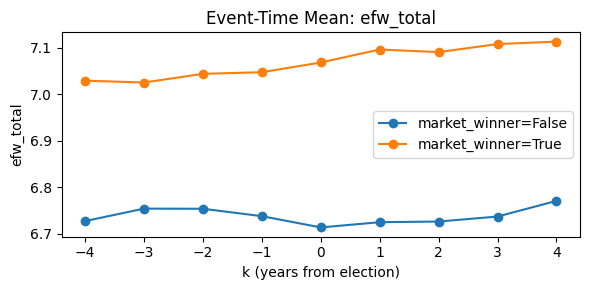

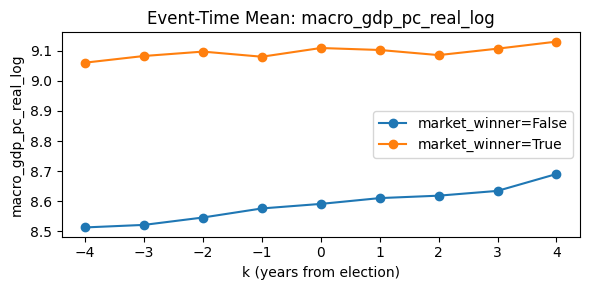

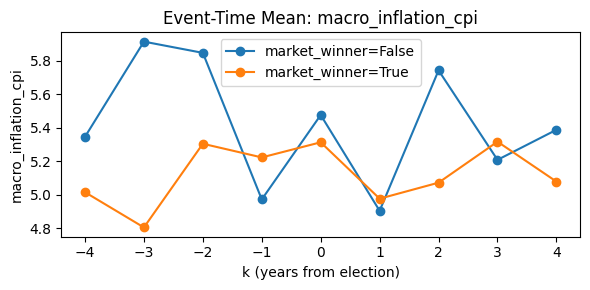

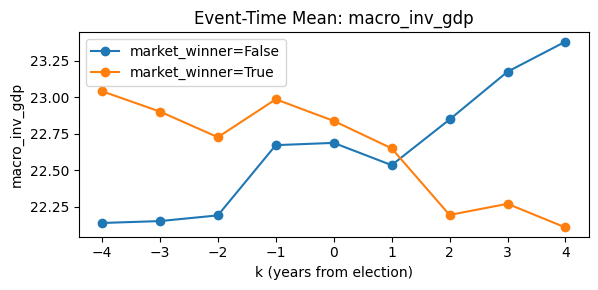

In [8]:
# Event-time descriptive plots (non-causal)

# Prepare event-time dataset
k_vals = list(range(-4,5))
rows = []
for _, row in elec.iterrows():
    if pd.isna(row['election_year']):
        continue
    for k in k_vals:
        rows.append({
            'iso3': row['iso3'],
            'event_id': row['event_id'],
            'event_year': int(row['election_year']),
            'year': int(row['election_year']) + k,
            'k': k,
            'market_winner': row.get('market_winner', np.nan),
            'office_type': row.get('office_type', None),
            'share_metric': row.get('share_metric', None)
        })

et = pd.DataFrame(rows)
et = et.merge(panel[['iso3','year','efw_total','macro_gdp_pc_real_log','macro_inflation_cpi','macro_inv_gdp']], on=['iso3','year'], how='left')

# Plot mean outcomes by k, split by market_winner when available
for outcome in ['efw_total','macro_gdp_pc_real_log','macro_inflation_cpi','macro_inv_gdp']:
    if outcome not in et.columns:
        continue
    plt.figure(figsize=(6,3))
    for label, g in et.groupby('market_winner'):
        if pd.isna(label):
            continue
        series = g.groupby('k')[outcome].mean()
        plt.plot(series.index, series.values, marker='o', label=f'market_winner={label}')
    plt.title(f'Event-Time Mean: {outcome}')
    plt.xlabel('k (years from election)')
    plt.ylabel(outcome)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PATHS['reports'] / 'efw_annual_audit' / 'figures' / f'event_time_{outcome}.png', dpi=150)
    plt.show()


Large EFW increase events: 61


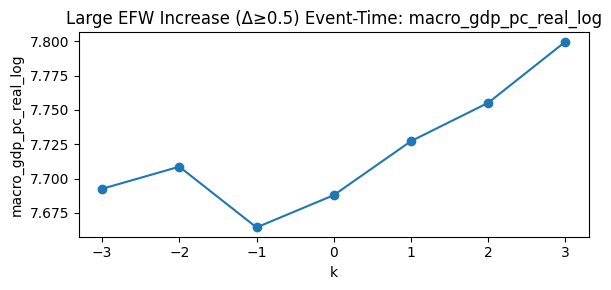

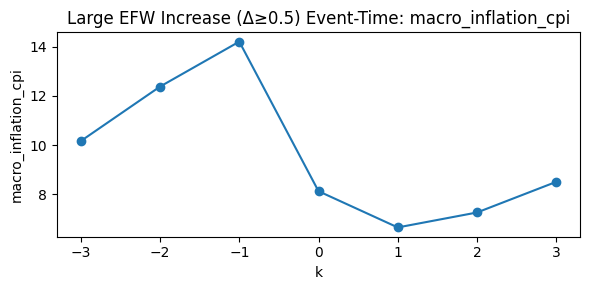

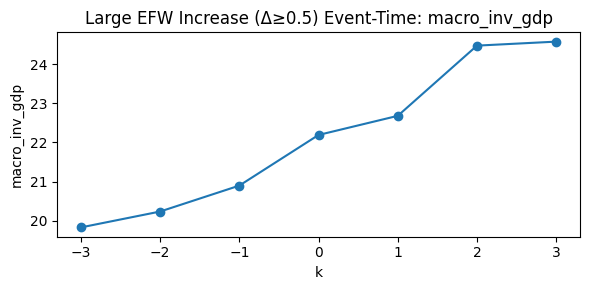

In [9]:
# Large EFW change events
panel = panel.sort_values(['iso3','year'])
panel['efw_delta_1y'] = panel.groupby('iso3')['efw_total'].diff()
threshold = 0.5
large = panel[panel['efw_delta_1y'] >= threshold]
print('Large EFW increase events:', len(large))

rows = []
for _, row in large.iterrows():
    for k in range(-3,4):
        rows.append({'iso3': row['iso3'], 'event_year': int(row['year']), 'year': int(row['year']) + k, 'k': k})

le = pd.DataFrame(rows)
le = le.merge(panel[['iso3','year','macro_gdp_pc_real_log','macro_inflation_cpi','macro_inv_gdp']], on=['iso3','year'], how='left')

for outcome in ['macro_gdp_pc_real_log','macro_inflation_cpi','macro_inv_gdp']:
    if outcome not in le.columns:
        continue
    series = le.groupby('k')[outcome].mean()
    plt.figure(figsize=(6,3))
    plt.plot(series.index, series.values, marker='o')
    plt.title(f'Large EFW Increase (Δ≥{threshold}) Event-Time: {outcome}')
    plt.xlabel('k')
    plt.ylabel(outcome)
    plt.tight_layout()
    plt.savefig(PATHS['reports'] / 'efw_annual_audit' / 'figures' / f'efw_large_change_event_time_{outcome}.png', dpi=150)
    plt.show()


In [10]:
# Ready-for-identification checklist
checklist = []

checklist.append({'sample': 'annual_efw_panel_2000_2023', 'n_rows': int(len(panel)), 'n_iso3': int(panel['iso3'].nunique())})

core_vars = ['macro_gdp_pc_real_log','macro_inflation_cpi','macro_inv_gdp','macro_trade_gdp']
mask_core = panel[core_vars].notna().all(axis=1)
checklist.append({'sample': 'with_macro_core', 'n_rows': int(mask_core.sum()), 'n_iso3': int(panel[mask_core]['iso3'].nunique())})

mask_timing = panel['elec_last_year'].notna() if 'elec_last_year' in panel.columns else pd.Series([False]*len(panel))
checklist.append({'sample': 'with_election_timing', 'n_rows': int(mask_timing.sum()), 'n_iso3': int(panel[mask_timing]['iso3'].nunique())})

mask_ideo = panel['elec_last_winner_ideo'].notna() if 'elec_last_winner_ideo' in panel.columns else pd.Series([False]*len(panel))
checklist.append({'sample': 'with_ideology_ok', 'n_rows': int(mask_ideo.sum()), 'n_iso3': int(panel[mask_ideo]['iso3'].nunique())})

# RD-ready subset based on elections data (close <=5pp with both ideologies ok)
rd_ready = elec[(elec.get('analysis_ideo_ok', False) == True) & (elec.get('close_5pp', False) == True)]
checklist.append({'sample': 'rd_ready_close5pp_elections', 'n_rows': int(len(rd_ready)), 'n_iso3': int(rd_ready['iso3'].nunique())})

checklist_df = pd.DataFrame(checklist)
write_parquet_pyarrow(checklist_df, PATHS['reports'] / 'efw_annual_audit' / 'ready_checklist.parquet')
show_table(checklist_df, title='Ready-for-Identification Checklist')


Ready-for-Identification Checklist


,sample,n_rows,n_iso3
0,annual_efw_panel_2000_2023,3960,165
1,with_macro_core,3340,151
2,with_election_timing,3529,160
3,with_ideology_ok,580,141
4,rd_ready_close5pp_elections,102,49


In [11]:
# Save annual panel and audit log
out_path = PATHS['data_processed'] / 'panel_efw_annual.parquet'
write_parquet_pyarrow(panel, out_path)
print('wrote', out_path)

if AUDIT_LOG:
    audit_df = pd.DataFrame(AUDIT_LOG)
    write_parquet_pyarrow(audit_df, PATHS['reports'] / 'efw_annual_audit' / 'audit_log.parquet')
    show_table(audit_df, title='Audit Log')


wrote /Users/gabrielsaco/Documents/GitHub/economic-freedom/data/processed/panel_efw_annual.parquet
Audit Log


,step,n_rows,n_cols,n_iso3,notes,n_dupe_rows_on_keys,left_rows,right_rows,merged_rows,matched_rows,left_only_rows,right_only_rows,on_keys,how
0,loaded_efw_annual,3960.0,12.0,165.0,,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,loaded_elections_post2000,1397.0,84.0,160.0,,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,merge_macro,NaN,NaN,NaN,NaN,NaN,3960.0,11718.0,3960.0,3936.0,24.0,0.0,"iso3,year",left
